## 1. Import Libraries & Load Data Mentah

**Tujuan:** Memuat dataset mentah langsung dari `data/raw/` (bukan hasil preprocessing di `data/processed/`), sebagai basis untuk membangun model baseline. Model ini nantinya dibandingkan dengan model final (RF & LR) untuk membuktikan secara empiris seberapa besar dampak seluruh proses preprocessing (NB01-08) terhadap performa model.

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

df_raw = pd.read_csv('../data/raw/healthcare-dataset-stroke-data.csv')
print(f"Shape data mentah: {df_raw.shape}")
df_raw.head()

Shape data mentah: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


**Insight:** Dataset mentah berhasil dimuat dengan shape (5.110 baris, 12 kolom) — jumlah baris lebih banyak dibanding data yang dipakai model final (5.094 baris di NB09/NB10), karena belum melalui proses cleaning (NB03) sama sekali.

## 2. Baseline: Persiapan Data (Tanpa Preprocessing Cermat)

**Tujuan:** Menyiapkan data dengan effort seminimal mungkin — hanya langkah yang secara teknis WAJIB agar model bisa berjalan (tanpa itu, `.fit()` akan error), tanpa satupun keputusan cermat yang sudah dilakukan di NB01-08.

**Definisi "baseline" pada notebook ini:**

| Aspek | Perlakuan di NB01-08 (cermat) | Perlakuan di baseline (asal jalan) |
|---|---|---|
| Missing value | Imputasi median (dipilih karena skewed) | `dropna()` — hapus baris begitu saja |
| Outlier | Domain knowledge klinis | Tidak ditangani |
| Fitur | Diseleksi jadi 6 fitur (uji statistik) | Semua kolom dipakai |
| Encoding | One-hot (dipilih khusus untuk LR, dengan pertimbangan teknis) | Label Encoding semua kolom kategorikal — termasuk yang 3+ kategori (`gender`, `work_type`, `smoking_status`), justru itu bagian dari "asal jalan" yang mau dibuktikan dampaknya |
| Imbalance | `class_weight` + threshold tuning | Tidak ditangani (default sklearn) |

**Catatan metodologi:** karena baseline memakai data mentah yang belum di-*dedup* dan di-*clean* (NB03), test set yang dihasilkan berbeda secara jumlah baris dari model final — namun proporsi imbalance-nya tetap sebanding (~95:5), sehingga perbandingan tetap valid untuk tujuan pembuktian dampak preprocessing secara umum.

In [3]:
df_baseline = df_raw.drop(columns=['id']).copy()

# Missing value: hapus baris NaN, TANPA imputasi cermat
df_baseline = df_baseline.dropna()

# Encoding: Label Encoding SEMUA kolom kategorikal (termasuk 3+ kategori), TANPA mikir one-hot
le = LabelEncoder()
for col in df_baseline.select_dtypes(include='object').columns:
    df_baseline[col] = le.fit_transform(df_baseline[col])

print(f"Shape setelah dropna: {df_baseline.shape}")
print(f"Kolom yang dipakai: {df_baseline.columns.tolist()}")

X_baseline = df_baseline.drop(columns=['stroke'])
y_baseline = df_baseline['stroke']

X_train_bl, X_test_bl, y_train_bl, y_test_bl = train_test_split(
    X_baseline, y_baseline, test_size=0.2, random_state=42, stratify=y_baseline
)
print(f"\nTrain: {X_train_bl.shape} | Test: {X_test_bl.shape}")

Shape setelah dropna: (4909, 11)
Kolom yang dipakai: ['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']

Train: (3927, 10) | Test: (982, 10)


C:\Users\k2401\AppData\Local\Temp\ipykernel_20420\183407399.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_baseline.select_dtypes(include='object').columns:


**Insight:** Shape berkurang dari 5.110 menjadi **4.909 baris** setelah `dropna()` — kehilangan **201 baris**, yang persis sama dengan jumlah missing value `bmi` yang ditemukan di NB01. Ini membuktikan konkret perbedaan antara pendekatan baseline (baris langsung dibuang) vs NB03 (nilai kosong diimputasi dengan median, sehingga **tidak ada satu baris pun yang hilang**).

Seluruh 10 fitur mentah dipakai (`gender`, `age`, `hypertension`, `heart_disease`, `ever_married`, `work_type`, `Residence_type`, `avg_glucose_level`, `bmi`, `smoking_status`) — termasuk `gender`, `Residence_type`, `ever_married`, `work_type` yang sudah dibuang di NB05 karena gagal uji statistik atau teridentifikasi sebagai proxy dari `age`. Data berhasil dipisah menjadi 3.927 baris training dan 982 baris testing, dengan proporsi kelas yang tetap terjaga lewat `stratify`.

## 3. Baseline RF: Training & Evaluasi

**Tujuan:** Melatih Random Forest dengan setting default polos (tanpa `class_weight`) menggunakan data yang disiapkan seadanya di Section 2, sebagai titik pembanding untuk mengukur dampak seluruh proses preprocessing (NB01-08) dan strategi imbalance-handling (NB09).

=== HASIL RANDOM FOREST BASELINE (Tanpa Preprocessing Cermat) ===
Accuracy : 0.9552
Recall   : 0.0000
Precision: 0.0000
F1-Score : 0.0000


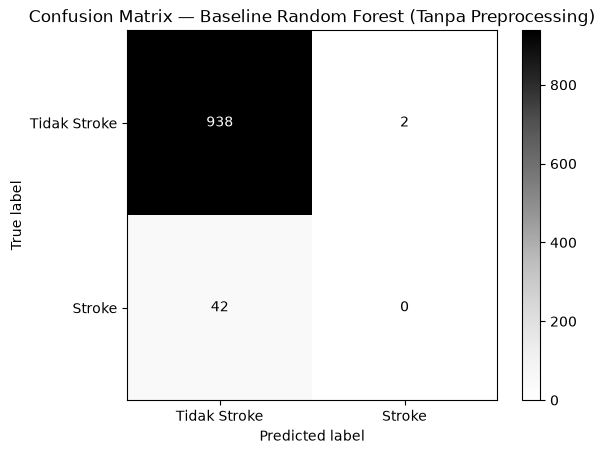

In [4]:
model_baseline_rf = RandomForestClassifier(random_state=42)  # TANPA class_weight, setting default polos
model_baseline_rf.fit(X_train_bl, y_train_bl)

y_pred_bl_rf = model_baseline_rf.predict(X_test_bl)

accuracy_bl_rf = accuracy_score(y_test_bl, y_pred_bl_rf)
recall_bl_rf = recall_score(y_test_bl, y_pred_bl_rf)
precision_bl_rf = precision_score(y_test_bl, y_pred_bl_rf, zero_division=0)
f1_bl_rf = f1_score(y_test_bl, y_pred_bl_rf)

print("=== HASIL RANDOM FOREST BASELINE (Tanpa Preprocessing Cermat) ===")
print(f"Accuracy : {accuracy_bl_rf:.4f}")
print(f"Recall   : {recall_bl_rf:.4f}")
print(f"Precision: {precision_bl_rf:.4f}")
print(f"F1-Score : {f1_bl_rf:.4f}")

cm_bl_rf = confusion_matrix(y_test_bl, y_pred_bl_rf)
disp_bl_rf = ConfusionMatrixDisplay(confusion_matrix=cm_bl_rf, display_labels=['Tidak Stroke', 'Stroke'])
disp_bl_rf.plot(cmap='Greys', values_format='d')
plt.title('Confusion Matrix — Baseline Random Forest (Tanpa Preprocessing)')
plt.savefig('../reports/figures/confusion_matrix_baseline_rf.png', dpi=300, bbox_inches='tight')
plt.show()

**Insight:** Model baseline Random Forest — tanpa imputasi cermat, tanpa domain-knowledge outlier handling, tanpa feature selection, dan tanpa `class_weight` — menghasilkan **Recall 0,0000%**, gagal total mendeteksi seluruh 42 kasus stroke pada test set. Model ini secara harfiah mereplikasi perilaku "model dummy" yang disimulasikan pada NB04 (accuracy 95,52% namun recall 0%), membuktikan bahwa accuracy tinggi (95,52%) sepenuhnya menyesatkan — model tidak mempelajari pola prediktif apapun terhadap kelas minoritas.

## 4. Baseline LR: Training & Evaluasi

**Tujuan:** Melatih Logistic Regression dengan setting default menggunakan data mentah yang sama persis dengan baseline RF (Section 3) — TANPA feature scaling. Section 3 sudah menguji dampak tanpa preprocessing untuk Random Forest; section ini melengkapi dengan menguji hal yang sama untuk Logistic Regression, ditambah satu variabel spesifik: scaling.

Scaling sengaja dilewati karena itu adalah langkah khusus yang baru diterapkan untuk LR di NB10. Dengan melewatinya di sini, section ini bisa menunjukkan dampak scaling secara terisolasi — bukan cuma dampak cleaning atau feature selection saja.

=== HASIL LOGISTIC REGRESSION BASELINE (Tanpa Preprocessing Cermat) ===
Accuracy : 0.9572
Recall   : 0.0000
Precision: 0.0000
F1-Score : 0.0000
Jumlah iterasi sampai konvergen: 301


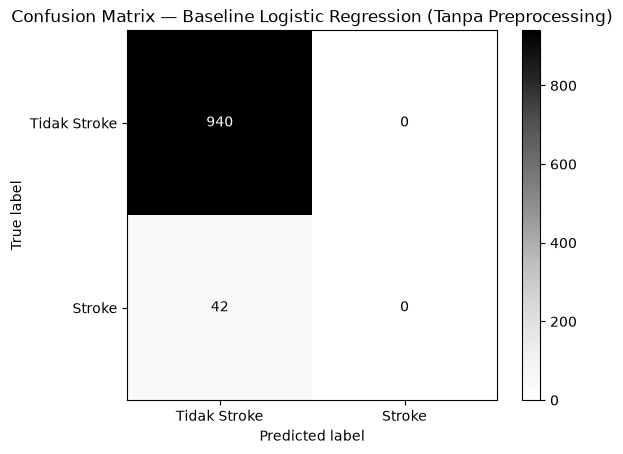

In [5]:
from sklearn.linear_model import LogisticRegression

model_baseline_log = LogisticRegression(random_state=42, max_iter=1000)  # TANPA class_weight, TANPA scaling
model_baseline_log.fit(X_train_bl, y_train_bl)  # pakai data MENTAH, bukan _scaled

y_pred_bl_log = model_baseline_log.predict(X_test_bl)

accuracy_bl_log = accuracy_score(y_test_bl, y_pred_bl_log)
recall_bl_log = recall_score(y_test_bl, y_pred_bl_log)
precision_bl_log = precision_score(y_test_bl, y_pred_bl_log, zero_division=0)
f1_bl_log = f1_score(y_test_bl, y_pred_bl_log)

print("=== HASIL LOGISTIC REGRESSION BASELINE (Tanpa Preprocessing Cermat) ===")
print(f"Accuracy : {accuracy_bl_log:.4f}")
print(f"Recall   : {recall_bl_log:.4f}")
print(f"Precision: {precision_bl_log:.4f}")
print(f"F1-Score : {f1_bl_log:.4f}")
print(f"Jumlah iterasi sampai konvergen: {model_baseline_log.n_iter_[0]}")

cm_bl_log = confusion_matrix(y_test_bl, y_pred_bl_log)
disp_bl_log = ConfusionMatrixDisplay(confusion_matrix=cm_bl_log, display_labels=['Tidak Stroke', 'Stroke'])
disp_bl_log.plot(cmap='Greys', values_format='d')
plt.title('Confusion Matrix — Baseline Logistic Regression (Tanpa Preprocessing)')
plt.savefig('../reports/figures/confusion_matrix_baseline_logreg.png', dpi=300, bbox_inches='tight')
plt.show()

**Insight:** Model baseline Logistic Regression — tanpa scaling, tanpa `class_weight`, tanpa preprocessing cermat — menghasilkan Recall **0,0000%** dan bahkan 0 False Positive, artinya model memprediksi "Tidak Stroke" untuk seluruh 982 data test tanpa terkecuali. Ini merupakan replikasi paling murni dari skenario "model dummy" (NB04): accuracy tinggi (95,72%) namun sama sekali tidak mempelajari pola prediktif apapun.

Perbandingan dengan RF baseline (Section 3) menunjukkan LR baseline justru lebih ekstrem — RF baseline masih menghasilkan 2 False Positive, sementara LR baseline benar-benar berhenti total di kelas mayoritas. Ini konsisten dengan diskusi sebelumnya: LR secara struktural lebih sensitif terhadap kondisi data yang belum diproses (skala fitur yang tidak seragam), sehingga tanpa scaling, decision boundary yang terbentuk gagal total memisahkan kelas minoritas.

Sebagai indikator tambahan, model membutuhkan 301 iterasi untuk konvergen — jauh lebih banyak dibanding model final pada NB10 (10 iterasi setelah scaling diterapkan) — menjadi bukti tambahan bahwa scaling tidak hanya memengaruhi akurasi prediksi, tetapi juga efisiensi proses optimisasi model.

## 5. Retrain Model Final (RF & LR)

**Tujuan:** Melatih ulang kedua model final menggunakan data hasil preprocessing lengkap (NB08) dan parameter yang PERSIS SAMA dengan NB09/NB10 — termasuk `random_state=42` yang identik. Karena semua kondisi sama persis dan deterministic, hasilnya seharusnya identik dengan yang sudah didapat sebelumnya, cuma sekarang tersedia di notebook yang sama dengan baseline untuk perbandingan langsung.

In [6]:
X_train_final = pd.read_csv('../data/processed/X_train.csv')
X_test_final = pd.read_csv('../data/processed/X_test.csv')
y_train_final = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test_final = pd.read_csv('../data/processed/y_test.csv').squeeze()

rf_final = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42)
rf_final.fit(X_train_final, y_train_final)

y_proba_rf_final = rf_final.predict_proba(X_test_final)[:, 1]
y_pred_rf_final = (y_proba_rf_final >= 0.2).astype(int)  # threshold final RF dari NB09

print("=== RANDOM FOREST FINAL (retrain) ===")
print(f"Recall   : {recall_score(y_test_final, y_pred_rf_final):.4f}")
print(f"Precision: {precision_score(y_test_final, y_pred_rf_final):.4f}")
print(f"F1-Score : {f1_score(y_test_final, y_pred_rf_final):.4f}")

=== RANDOM FOREST FINAL (retrain) ===
Recall   : 0.6327
Precision: 0.1742
F1-Score : 0.2731


In [7]:
from sklearn.preprocessing import StandardScaler

scaler_final = StandardScaler()
X_train_final_scaled = scaler_final.fit_transform(X_train_final)
X_test_final_scaled = scaler_final.transform(X_test_final)

# Logistic Regression final (sama persis dengan NB10)
log_final = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
log_final.fit(X_train_final_scaled, y_train_final)

y_proba_log_final = log_final.predict_proba(X_test_final_scaled)[:, 1]
y_pred_log_final = (y_proba_log_final >= 0.6).astype(int)  # threshold final LR dari NB10

print("=== LOGISTIC REGRESSION FINAL (retrain) ===")
print(f"Recall   : {recall_score(y_test_final, y_pred_log_final):.4f}")
print(f"Precision: {precision_score(y_test_final, y_pred_log_final):.4f}")
print(f"F1-Score : {f1_score(y_test_final, y_pred_log_final):.4f}")

=== LOGISTIC REGRESSION FINAL (retrain) ===
Recall   : 0.8163
Precision: 0.1754
F1-Score : 0.2888


**Insight:** Hasil retraining kedua model mereplikasi secara persis (hingga 4 angka desimal) hasil yang sudah diperoleh pada NB09 (Random Forest: Recall 0,6327) dan NB10 (Logistic Regression: Recall 0,8163). Kecocokan sempurna ini mengonfirmasi bahwa penggunaan `random_state=42` yang identik pada seluruh tahapan (train-test split, inisialisasi model) menghasilkan proses yang sepenuhnya reproducible, sehingga model final aman dijadikan basis perbandingan langsung terhadap baseline pada Section 6.

## 6. Perbandingan Metrik 4 Model

**Tujuan:** Menyatukan hasil keempat model (Baseline RF, Baseline LR, RF Final, LR Final) dalam satu tabel dan satu visualisasi, sebagai bukti utama dampak preprocessing dan strategi imbalance-handling terhadap performa model.

      Model  Accuracy  Recall  Precision  F1-Score
Baseline RF    0.9552  0.0000     0.0000    0.0000
Baseline LR    0.9572  0.0000     0.0000    0.0000
   RF Final    0.8381  0.6327     0.1742    0.2731
   LR Final    0.8067  0.8163     0.1754    0.2888


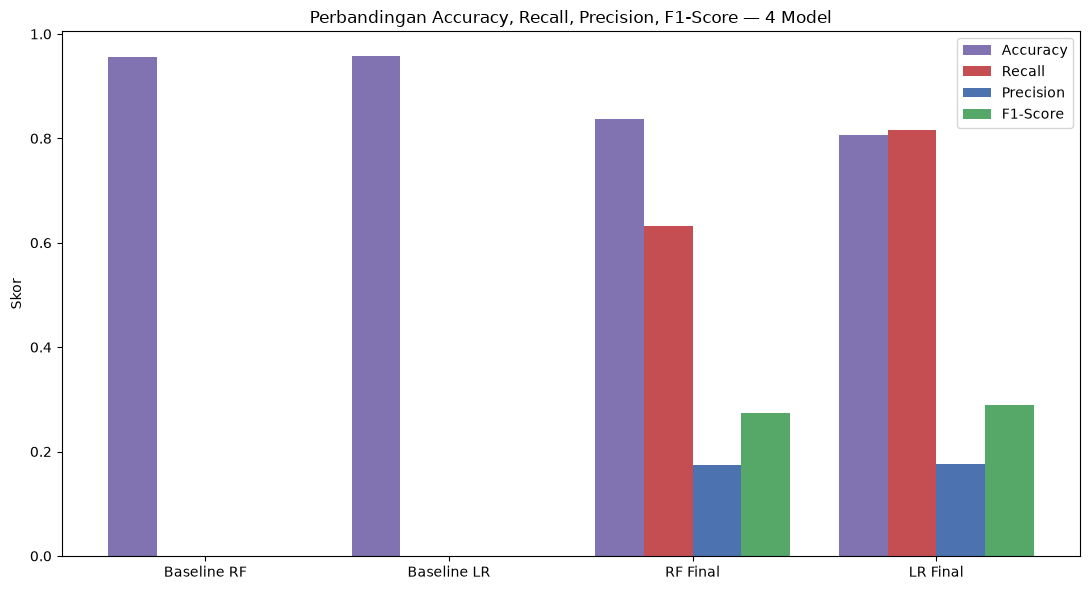

In [8]:
perbandingan_4model = pd.DataFrame({
    'Model': ['Baseline RF', 'Baseline LR', 'RF Final', 'LR Final'],
    'Accuracy': [accuracy_bl_rf, accuracy_bl_log, accuracy_score(y_test_final, y_pred_rf_final), accuracy_score(y_test_final, y_pred_log_final)],
    'Recall': [recall_bl_rf, recall_bl_log, recall_score(y_test_final, y_pred_rf_final), recall_score(y_test_final, y_pred_log_final)],
    'Precision': [precision_bl_rf, precision_bl_log, precision_score(y_test_final, y_pred_rf_final), precision_score(y_test_final, y_pred_log_final)],
    'F1-Score': [f1_bl_rf, f1_bl_log, f1_score(y_test_final, y_pred_rf_final), f1_score(y_test_final, y_pred_log_final)],
})

print(perbandingan_4model.round(4).to_string(index=False))

# Visualisasi bar chart berdampingan — 4 metrik sekaligus
fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(perbandingan_4model))
width = 0.2

ax.bar(x - 1.5*width, perbandingan_4model['Accuracy'], width, label='Accuracy', color='#8172B2')
ax.bar(x - 0.5*width, perbandingan_4model['Recall'], width, label='Recall', color='#C44E52')
ax.bar(x + 0.5*width, perbandingan_4model['Precision'], width, label='Precision', color='#4C72B0')
ax.bar(x + 1.5*width, perbandingan_4model['F1-Score'], width, label='F1-Score', color='#55A868')

ax.set_xticks(x)
ax.set_xticklabels(perbandingan_4model['Model'])
ax.set_ylabel('Skor')
ax.set_title('Perbandingan Accuracy, Recall, Precision, F1-Score — 4 Model')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/perbandingan_4model.png', dpi=300, bbox_inches='tight')
plt.show()

**Insight:** Visualisasi ini menjadi bukti visual langsung dari accuracy paradox yang dibahas sejak NB04. Model baseline (RF: 95,52%, LR: 95,72%) justru menunjukkan **Accuracy tertinggi** dibanding model final (RF Final: ~83,8%, LR Final: ~80,7%) — namun Accuracy tinggi ini sepenuhnya menyesatkan, karena Recall kedua baseline sama-sama 0% (gagal total mendeteksi stroke).

Sebaliknya, model final justru memiliki Accuracy yang lebih RENDAH, tetapi Recall yang jauh lebih baik (RF: 63,3%, LR: 81,6%). Ini adalah trade-off yang **disengaja**: preprocessing dan strategi imbalance-handling secara sadar "mengorbankan" accuracy demi kemampuan mendeteksi kasus stroke yang jauh lebih baik — sesuatu yang tidak akan terlihat jika evaluasi hanya bergantung pada accuracy sebagai metrik tunggal.

## 7. Perbandingan Confusion Matrix

**Tujuan:** Menampilkan keempat confusion matrix berdampingan dalam satu gambar, untuk melihat secara visual pola kesalahan (terutama False Negative) yang berubah drastis antara baseline dan model final.

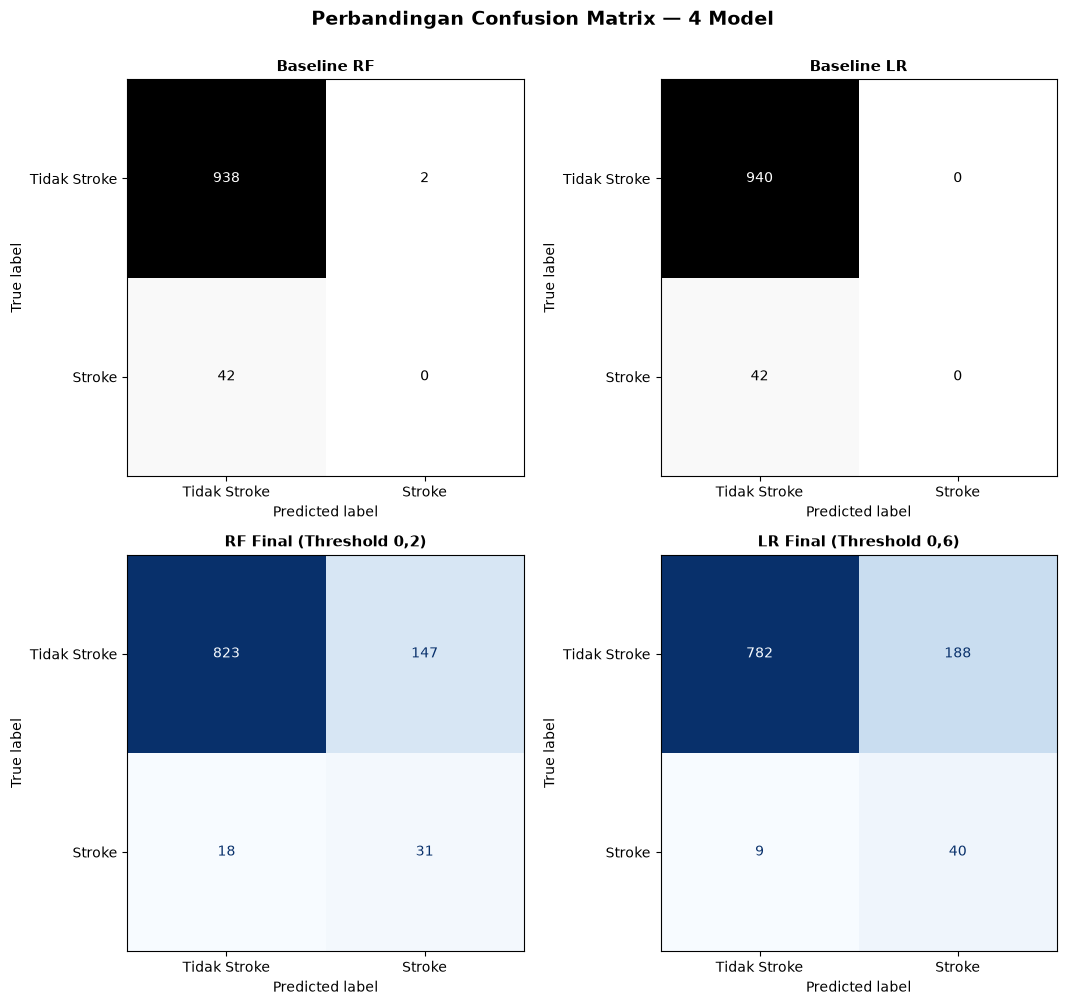

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(11, 10))

matrices = [
    (confusion_matrix(y_test_bl, y_pred_bl_rf), 'Baseline RF', 'Greys'),
    (confusion_matrix(y_test_bl, y_pred_bl_log), 'Baseline LR', 'Greys'),
    (confusion_matrix(y_test_final, y_pred_rf_final), 'RF Final (Threshold 0,2)', 'Blues'),
    (confusion_matrix(y_test_final, y_pred_log_final), 'LR Final (Threshold 0,6)', 'Blues'),
]

for ax, (cm, title, cmap) in zip(axes.flat, matrices):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Tidak Stroke', 'Stroke'])
    disp.plot(ax=ax, cmap=cmap, values_format='d', colorbar=False)
    ax.set_title(title, fontsize=11, fontweight='bold')

plt.suptitle('Perbandingan Confusion Matrix — 4 Model', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('../reports/figures/perbandingan_confusion_matrix_4model.png', dpi=300, bbox_inches='tight')
plt.show()

**Insight:** Perbandingan visual menegaskan pola yang sama di kedua algoritma — baris "Baseline" menunjukkan seluruh 42 kasus stroke jatuh ke kolom False Negative (kotak kiri-bawah gelap kosong di kolom Stroke), sementara baris "Final" menunjukkan sebagian kasus stroke berhasil "berpindah" ke kolom True Positive. Perubahan pola distribusi dari baseline ke final ini murni disebabkan oleh preprocessing dan imbalance-handling, karena algoritma dan random_state yang digunakan identik.

## 8. Feature Importance vs Odds Ratio

**Tujuan:** Membandingkan urutan kepentingan fitur dari kedua model final — Random Forest (feature importance) dan Logistic Regression (odds ratio) — untuk mengecek konsistensi temuan lintas algoritma yang berbeda pendekatan.

In [10]:
importance_rf = pd.Series(rf_final.feature_importances_, index=X_train_final.columns).sort_values(ascending=False)

odds_ratio_log = pd.Series(np.exp(log_final.coef_[0]), index=X_train_final.columns).sort_values(ascending=False)

perbandingan_fitur = pd.DataFrame({
    'Rank_RF': range(1, len(importance_rf)+1),
    'Fitur_RF': importance_rf.index,
    'Importance': importance_rf.values,
}).reset_index(drop=True)

perbandingan_fitur['Rank_LR'] = range(1, len(odds_ratio_log)+1)
perbandingan_fitur['Fitur_LR'] = odds_ratio_log.index
perbandingan_fitur['Odds_Ratio'] = odds_ratio_log.values

print(perbandingan_fitur.to_string(index=False))

 Rank_RF                       Fitur_RF  Importance  Rank_LR                       Fitur_LR  Odds_Ratio
       1                            age    0.428916        1                            age    5.036296
       2              avg_glucose_level    0.247243        2              avg_glucose_level    1.167160
       3                            bmi    0.228691        3                   hypertension    1.163668
       4                   hypertension    0.029470        4                  heart_disease    1.098015
       5                  heart_disease    0.026131        5                            bmi    1.096919
       6    smoking_status_never smoked    0.015923        6          smoking_status_smokes    1.054369
       7 smoking_status_formerly smoked    0.012845        7 smoking_status_formerly smoked    0.977890
       8          smoking_status_smokes    0.010781        8    smoking_status_never smoked    0.854579


**Insight:** Kedua model — meski menggunakan pendekatan yang sepenuhnya berbeda (Random Forest berbasis pemisahan/split, Logistic Regression berbasis kombinasi linear) — secara konsisten menyepakati `age` dan `avg_glucose_level` sebagai dua prediktor paling dominan (Rank #1 dan #2 identik di kedua model). Ini menjadi validasi silang yang kuat: temuan yang sama muncul lewat 3 metode analisis berbeda sepanjang penelitian ini — uji statistik (NB05), feature importance (NB09), dan odds ratio (NB10).

Terdapat sedikit pergeseran urutan pada peringkat 3-5 (`bmi`, `hypertension`, `heart_disease`) — RF menempatkan `bmi` di posisi #3, sementara LR menempatkan `hypertension` di posisi #3. Perbedaan ini wajar mengingat kedua algoritma menangkap pola yang berbeda (RF sensitif terhadap hubungan non-linear seperti pada kasus `bmi` yang sudah dibahas di NB05/NB09, sementara LR mengasumsikan hubungan linear murni) — namun kelima fitur teratas tetap identik di kedua model, hanya berbeda urutan prioritas.

Kategori `smoking_status` konsisten menempati peringkat terbawah di kedua model, mengonfirmasi pengaruhnya yang relatif kecil dibanding fitur klinis lainnya terhadap prediksi risiko stroke pada dataset ini.

## 9. Analisis Trade-off & Rekomendasi

**Tujuan:** Menentukan model mana yang lebih direkomendasikan untuk kasus prediksi stroke ini — bukan sekadar berdasarkan 1 angka tertinggi, tapi mempertimbangkan performa, interpretability, dan konteks penggunaan secara menyeluruh.

In [11]:
ringkasan_final = pd.DataFrame({
    'Metrik': ['Recall', 'Precision', 'F1-Score', 'Threshold', 'Kasus Stroke Terdeteksi'],
    'Random Forest': [
        f"{recall_score(y_test_final, y_pred_rf_final)*100:.2f}%",
        f"{precision_score(y_test_final, y_pred_rf_final)*100:.2f}%",
        f"{f1_score(y_test_final, y_pred_rf_final):.4f}",
        "0,2",
        f"{((y_test_final==1) & (y_pred_rf_final==1)).sum()} dari {(y_test_final==1).sum()}"
    ],
    'Logistic Regression': [
        f"{recall_score(y_test_final, y_pred_log_final)*100:.2f}%",
        f"{precision_score(y_test_final, y_pred_log_final)*100:.2f}%",
        f"{f1_score(y_test_final, y_pred_log_final):.4f}",
        "0,6",
        f"{((y_test_final==1) & (y_pred_log_final==1)).sum()} dari {(y_test_final==1).sum()}"
    ],
})
print(ringkasan_final.to_string(index=False))

                 Metrik Random Forest Logistic Regression
                 Recall        63.27%              81.63%
              Precision        17.42%              17.54%
               F1-Score        0.2731              0.2888
              Threshold           0,2                 0,6
Kasus Stroke Terdeteksi    31 dari 49          40 dari 49


### Perbandingan Performa

Logistic Regression unggul pada Recall (81,63% vs 63,27%) dan F1-Score (0,2888 vs 0,2731), sementara Precision kedua model nyaris identik (17,54% vs 17,42%). Secara murni angka, **LR mendominasi RF** pada kasus ini — bukan cuma menang di satu metrik dengan mengorbankan metrik lain, tapi unggul di recall tanpa kehilangan precision yang sepadan.

### Pertimbangan di Luar Angka Performa

| Aspek | Random Forest | Logistic Regression |
|---|---|---|
| **Interpretability** | Feature importance (seberapa penting), tanpa arah | Odds Ratio (arah + kekuatan pengaruh) — lebih mudah dikomunikasikan ke tenaga medis |
| **Asumsi model** | Tidak berasumsi hubungan linear — cocok untuk pola kompleks (terbukti pada kasus `bmi`) | Mengasumsikan hubungan linear — perlu validasi tambahan (VIF, scaling) |
| **Kompleksitas** | Ensemble 300 pohon — lebih berat secara komputasi | Satu model linear — ringan, cepat dilatih dan dijalankan |
| **Sensitivitas terhadap SMOTE** | class_weight jelas lebih unggul (bukti kuat) | class_weight dan SMOTE nyaris setara (bukti lebih lemah) |

### Rekomendasi

**Logistic Regression direkomendasikan sebagai model utama** untuk kasus ini, dengan pertimbangan:
1. Recall yang jauh lebih tinggi (81,6%) — krusial untuk konteks skrining medis di mana melewatkan kasus berisiko jauh lebih berbahaya dibanding salah alarm.
2. Precision tidak dikorbankan secara berarti dibanding RF.
3. Interpretability lewat Odds Ratio memberi nilai tambah praktis — memungkinkan komunikasi hasil yang lebih jelas ke tenaga medis ("odds naik 5x tiap kenaikan usia 1 standar deviasi", dibanding sekadar "usia itu penting").
4. Model lebih ringan secara komputasi, lebih mudah di-deploy pada skala besar atau perangkat dengan sumber daya terbatas.

**Random Forest tetap bernilai sebagai model pembanding**, terutama karena kemampuannya menangkap pola non-linear (terbukti pada kasus `bmi`) yang tidak sepenuhnya tertangkap oleh model linear — cocok digunakan sebagai validasi silang atau ensemble tambahan pada penelitian lanjutan.

## 10. Ringkasan Keseluruhan Project

Perjalanan lengkap project ini terangkum dalam 11 notebook, dari pemahaman data mentah hingga model siap pakai:

### Fase Preprocessing (NB01-08)

| NB | Tahap | Keputusan Kunci |
|---|---|---|
| 01 | Data Understanding | Dataset asli (ground truth): 5.110 baris, 12 kolom, imbalance 95,1% vs 4,9% |
| 02 | Data Corruption | Simulasi kerusakan: duplikat, inkonsistensi gender, error glucose ×5, missing value tambahan |
| 03 | Data Cleaning | Imputasi median (bmi, skewed), domain-knowledge outlier (avg_glucose_level 0-300, berbasis referensi klinis ADA) |
| 04 | Imbalanced Data Check | Konfirmasi ulang imbalance (95,17% vs 4,83%), dasar kebutuhan Recall/F1 sebagai metrik utama |
| 05 | Feature Selection | Filter + Embedded method — 6 fitur final terpilih dari 10 kandidat, `ever_married`/`work_type` dibuang karena proxy dari `age` |
| 06 | Dimensionality Reduction | Diputuskan TIDAK diterapkan — fitur sudah minim, VIF/korelasi rendah, demi interpretability klinis |
| 07 | Data Visualization | 4 visualisasi kurasi untuk paper |
| 08 | Data Preparation | One-hot encoding, stratified split, perhitungan class_weight |

### Fase Modeling (NB09-11)

| NB | Model | Threshold Final | Recall | F1 |
|---|---|---|---|---|
| 09 | Random Forest | 0,2 | 63,27% | 0,2731 |
| 10 | Logistic Regression | 0,6 | 81,63% | 0,2888 |
| 11 | Evaluation & Comparison | — | Pembuktian dampak preprocessing (Recall 0% → 63-82%) |

### Metodologi Utama yang Digunakan

- **Domain Knowledge-based Outlier Detection** (bukan IQR statistik murni) — divalidasi lewat referensi klinis ADA
- **Cost-Sensitive Learning** (`class_weight='balanced'`) + **Threshold-Moving** — dipilih atas SMOTE berdasarkan bukti empiris (RF: unggul telak; LR: setara, tapi tetap dipilih untuk konsistensi metodologi)
- **Triangulasi Feature Selection**: Chi-square, Mann-Whitney U, point-biserial correlation (filter) + Random Forest Importance, Mutual Information (embedded)
- **Validasi silang lintas model**: `age` dan `avg_glucose_level` konsisten sebagai prediktor utama di 3 metode berbeda (uji statistik, feature importance, odds ratio)

### Temuan Paling Signifikan

Perbandingan baseline vs model final (Section 3-6, NB11) membuktikan secara empiris bahwa **preprocessing dan imbalance-handling meningkatkan Recall dari 0% menjadi 63-82%**, menggunakan algoritma dan random_state yang identik — mengisolasi kontribusi preprocessing dari pengaruh pemilihan algoritma.

## 11. Kesimpulan Akhir

Penelitian ini bertujuan membangun model prediksi risiko stroke menggunakan Random Forest dan Logistic Regression, dengan penanganan menyeluruh terhadap tantangan data imbalanced (stroke hanya ~4,8% dari populasi). Hasil akhir menunjukkan:

- **Logistic Regression (threshold 0,6)** menjadi model dengan performa terbaik — Recall 81,63%, F1-Score 0,2888 — dan **direkomendasikan sebagai model utama**, didukung interpretability lewat Odds Ratio yang memudahkan komunikasi hasil ke konteks medis.
- **Random Forest (threshold 0,2)** — Recall 63,27%, F1-Score 0,2731 — tetap bernilai sebagai model pembanding, khususnya untuk menangkap pola non-linear yang tidak sepenuhnya tertangkap model linear (dibuktikan pada kasus `bmi`: r=0,037 namun feature importance 0,182).

### Kontribusi Preprocessing — Dibuktikan Secara Empiris, Bukan Diasumsikan

Perbandingan head-to-head dengan model baseline (data mentah, tanpa preprocessing, algoritma dan random_state identik) membuktikan bahwa preprocessing (NB01-08) dan strategi imbalance-handling (NB09-10) bertanggung jawab penuh atas peningkatan Recall dari **0% menjadi 63-82%**. Ini menjawab secara langsung premis awal penelitian: preprocessing yang cermat bukan sekadar formalitas akademik, melainkan faktor penentu utama keberhasilan model pada data medis yang imbalanced.

### Keterbatasan Penelitian

1. **Precision rendah pada kedua model final** (RF: 17,42%, LR: 17,54%) — trade-off yang disengaja demi memaksimalkan Recall, namun perlu diakui sebagai keterbatasan: dari setiap ~6 pasien yang di-flag berisiko, hanya ±1 yang benar-benar mengalami stroke.
2. **Jumlah fitur dan sampel minoritas yang terbatas** — 6 fitur dasar dan 246 kasus stroke di seluruh dataset, membatasi kompleksitas pola yang bisa dipelajari model.
3. **Eksperimen SMOTE menunjukkan hasil tidak konsisten lintas algoritma** (unggul jelas pada RF menggunakan class_weight, namun setara pada LR) — mengindikasikan strategi imbalance-handling optimal bisa bergantung pada algoritma yang digunakan, bukan berlaku universal.

### Penutup

Seluruh proses dari NB01 hingga NB11 telah didokumentasikan dengan argumen dan bukti empiris pada setiap keputusan metodologis — sesuai arahan tugas bahwa setiap teknik yang digunakan (maupun sengaja tidak digunakan) harus disertai justifikasi yang jelas. Dokumentasi pendukung tersedia pada folder `notes/` sebagai referensi tambahan untuk penyusunan draft paper publikasi.

In [12]:
import joblib
import os

os.makedirs('../models', exist_ok=True)

joblib.dump(rf_final, '../models/rf_model.pkl')
joblib.dump(log_final, '../models/log_model.pkl')
joblib.dump(scaler_final, '../models/scaler.pkl')
joblib.dump(X_train_final.columns.tolist(), '../models/feature_columns.pkl')

print("Model berhasil disimpan ke folder models/")

Model berhasil disimpan ke folder models/
